In [1]:
import numpy as np
import torch as torch
import os
import copy
import random
from scipy.optimize import nnls,curve_fit,leastsq
from sklearn.preprocessing import PolynomialFeatures
import time
from scipy.optimize import curve_fit,minimize
from scipy import stats

In [2]:
def equation(b, Dslow,Dfast,Fslow):
    return Fslow*np.exp(-b*Dslow) + (1-Fslow)*np.exp(-b*Dfast)

def fit_least_squares(X,Y,p0):
    try:
        bounds = ([0., 0, 0.], [3, 100., 1.])
        params, _ = curve_fit(equation, X, Y, p0=p0, bounds=bounds)
        dslow,dfast,fslow = params[0], params[1], params[2]
        return order(dslow,dfast,fslow)
    except:
        return np.array([0,0,0,0])
        
def order(Dslow,Dfast,Fslow):
    if Dfast < Dslow:
        Dfast, Dslow = Dslow, Dfast
        Fslow = 1-Fslow   
    return np.array([Dslow,Dfast,Fslow,1-Fslow])

def empirical_neg_log_prior(Dslow0, Dfast0, Fslow0):
    Dslow_valid = (1e-8 < np.nan_to_num(Dslow0)) & (np.nan_to_num(Dslow0) < 3 - 1e-8)
    Dfast_valid = (1e-8 < np.nan_to_num(Dfast0)) & (np.nan_to_num(Dfast0) < 100 - 1e-8)
    Fslow_valid = (1e-8 < np.nan_to_num(Fslow0)) & (np.nan_to_num(Fslow0) < 1 - 1e-8)
    valid = Dslow_valid & Dfast_valid & Fslow_valid
    Dslow0, Dfast0, Fslow0 = Dslow0[valid], Dfast0[valid], Fslow0[valid]
    
    Dslow_shape, _, Dslow_scale = stats.lognorm.fit(Dslow0, floc=0)
    Dfast_shape, _, Dfast_scale = stats.lognorm.fit(Dfast0, floc=0)
    Fslow_a, Fslow_b, _, _ = stats.beta.fit(Fslow0, floc=0, fscale=1)
    def neg_log_prior(p):
        Dslow, Dfast, Fslow, = p[0], p[1], p[2]
        if (Dfast < Dslow):
            return 1e8
        else:
            eps = 1e-8
            Dslow_prior = stats.lognorm.pdf(Dslow, Dslow_shape, scale=Dslow_scale)
            Dfast_prior = stats.lognorm.pdf(Dfast, Dfast_shape, scale=Dfast_scale)
            Fslow_prior = stats.beta.pdf(Fslow,Fslow_a, Fslow_b)
            return -np.log(Dslow_prior+eps) - np.log(Dfast_prior+eps) - np.log(Fslow_prior+eps)
    return neg_log_prior


def neg_log_likelihood(p, b, x_dw):
    return 0.5*(len(b)+1)*np.log(np.sum((equation(b, p[0], p[1], p[2])-x_dw)**2))

def neg_log_posterior(p, b, x_dw,neg_log_prior_fun):
    return neg_log_likelihood(p, b, x_dw) + neg_log_prior_fun(p)

def fit_bayesian(b_list, x_dw, x0,neg_log_prior_fun):
    try:
        if x_dw[0]<1e-8:
            return np.array([0,0,0,0]),100
        else:
            bounds = [(0., 3.), (0, 100), (0., 1.)]
            params = minimize(neg_log_posterior, x0=x0, args=(b_list, x_dw, neg_log_prior_fun), bounds=bounds)
            Dslow, Dfast, Fslow = params.x[0], params.x[1], params.x[2]
        return order(Dslow, Dfast, Fslow),params.fun
    except:
        return fit_least_squares(b_list, x_dw,b_list),100

def Bayesian(signals,neg_log_prior_fun,parameters0,b_list):
    x,y=signals.shape
    bayesian_parameters=np.zeros((x, 4)) 
    for i in range(x):
        Y=signals[i,:]
        if Y[0]<1e-5:
            bayesian_parameters[i,:]=np.array([0.,0.,0.,0.])
        else:
            loss_min=1000
            for j in range(len(parameters0)): 
                p=parameters0[j]
                temp_parameters,loss=fit_bayesian(b_list,Y,p,neg_log_prior_fun)
                if loss<loss_min:
                        loss_min=loss
                        parameters=temp_parameters 
            bayesian_parameters[i,:]=parameters
    bayesian_parameters[:,:2]=bayesian_parameters[:,:2]/1000
    return bayesian_parameters

In [3]:
data_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\data_dict.pth")
parameter_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\parameter_dict.pth")
error_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\error_dict.pth")

train_signals,_=data_dict['train']['Multi']
val_signals,val_parameters=data_dict['val']['Multi']

train_signals=train_signals[:,1:]/train_signals[:,0].reshape(-1,1)
val_signals=val_signals[:,1:]/val_signals[:,0].reshape(-1,1)
                          
b_list=np.array([30,50,100,150,300,400,500])/1000

ls_parameters=parameter_dict['lsq'+'train']

since = time.time()
Dslow0=ls_parameters[:,0].flatten()*1000
Dfast0=ls_parameters[:,1].flatten()*1000
Fslow0=ls_parameters[:,2].flatten()
neg_log_prior_fun=empirical_neg_log_prior(Dslow0, Dfast0, Fslow0)

bayesian_parameters=Bayesian(val_signals.numpy(),neg_log_prior_fun,[[0.75,100.,0.80]],b_list)
time_elapsed = time.time() - since
print("Training compete in {}m {}s".format(time_elapsed // 60, time_elapsed % 60))

Training compete in 4.0m 20.703800439834595s


In [4]:
parameter_dict['NLbayesian'+'val']=bayesian_parameters
diff_parameters=bayesian_parameters-np.array(val_parameters)
error_dict['NLbayesian'+'val']=diff_parameters

In [5]:
time_elapsed/val_parameters.shape[0]

0.02607038004398346

In [6]:
print(torch.mean((torch.tensor(bayesian_parameters)-val_parameters)*1000,dim=0))
print(torch.std((torch.tensor(bayesian_parameters)-val_parameters)*1000,dim=0))

tensor([ -0.0973, -48.0369, -23.4079,  23.4079], dtype=torch.float64)
tensor([ 0.1176, 32.2936, 40.9108, 40.9108], dtype=torch.float64)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


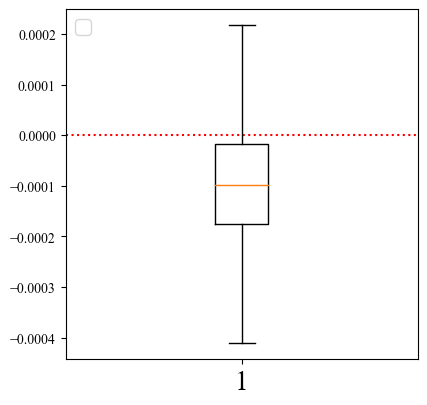

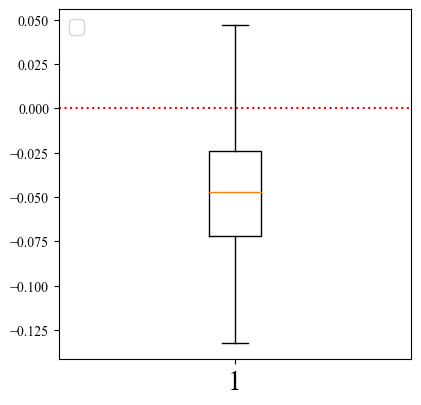

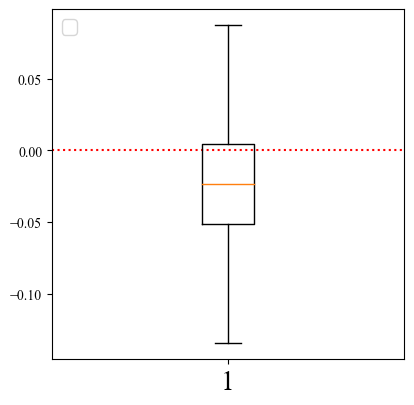

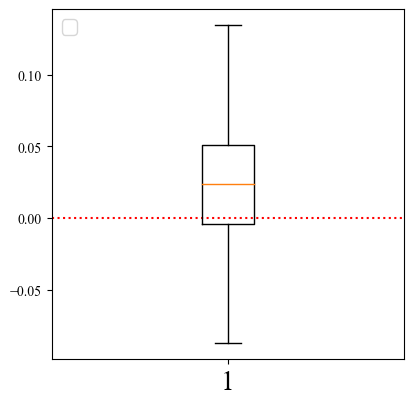

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters[:,0],showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,2)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters[:,1],showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,3)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters[:,2],showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,4)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters[:,3],showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

In [8]:
torch.save(parameter_dict,r"G:\zhouxinxiang\MRL_HN\simulation\parameter_dict.pth")
torch.save(error_dict,r"G:\zhouxinxiang\MRL_HN\simulation\error_dict.pth")